### Загрузка данных

EuroSAT датасет содержит мультиспектральные снимки (13 каналов).

In [2]:
import pandas as pd

train_df=pd.read_csv('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/train.csv')
val_df=pd.read_csv('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/validation.csv')
test_df=pd.read_csv('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/test.csv')

print(f'train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')

train: 19317, val: 5519, test: 2759


In [3]:
train_df.head()

,Filename,Label,ClassName
0,PermanentCrop/PermanentCrop_2401.tif,6,PermanentCrop
1,PermanentCrop/PermanentCrop_1006.tif,6,PermanentCrop
2,HerbaceousVegetation/HerbaceousVegetation_1025...,2,HerbaceousVegetation
3,SeaLake/SeaLake_1439.tif,9,SeaLake
4,River/River_1052.tif,8,River


### Класс датасета для 13-канальных TIFF
- Чтение 13-канального изображения через `tifffile.imread()` -> форма (64, 64, 13)
- `permute(2,0,1)` -> (13, 64, 64) для PyTorch
- Нормализация: каждый канал нормализуется отдельно (mean/std по пространственным осям)

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset
import tifffile

class EuroSATDataset(Dataset):
    def __init__(self, df, root_dir):
        self.df=df
        self.root_dir=root_dir
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        filename=self.df.iloc[i, 0] # изображение
        label=self.df.iloc[i,1] #класс

        # читаем 13-канальный tiff
        img_path=f'{self.root_dir}/{filename}'
        data= tifffile.imread(img_path) # (64, 64, 13)

        # конвертируем тензор и меняем порядок осей
        data=torch.tensor(data, dtype=torch.float32).permute(2,0,1) # (13, 64, 64)

        #нормализация (каждый канал отдельно)
        mean=data.mean(dim=(1,2))
        std=data.std(dim=(1,2))
        data=(data-mean[:, None, None])/(std[:, None, None] +1e-8)

        return data, label

In [5]:
from torch.utils.data import DataLoader

root_dir='/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands'

train_dataset=EuroSATDataset(train_df, root_dir)
val_dataset=EuroSATDataset(val_df, root_dir)
test_dataset=EuroSATDataset(test_df, root_dir)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'train батчей: {len(train_loader)}\nval батчей: {len(val_loader)}\ntest батчей: {len(test_loader)}')

train батчей: 604
val батчей: 173
test батчей: 87


### Архитектуры для мультиспектральных данных
Особенность: первый Conv2d принимает 13 каналов (вместо стандартных 3 для RGB).
- model1: базовый CNN без dropout
- model2: CNN с dropout (0.1–0.4) для регуляризации

In [7]:
from torch.nn import Sequential, Conv2d, MaxPool2d,Flatten, Linear, ReLU, BatchNorm2d, Dropout, AdaptiveAvgPool2d
from torchvision import models

model1=Sequential(
    # (13, 64, 64)
    Conv2d(13, 64, kernel_size=3, padding=1), # (64, 64, 64)
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2), # (64, 32, 32)

    Conv2d(64, 128, kernel_size=3, padding=1), # (128, 32, 32),
    BatchNorm2d(128),
    ReLU(),
    MaxPool2d(2), # (128, 16, 16)

    Conv2d(128, 256, kernel_size=3, padding=1), # (256, 16, 16)
    BatchNorm2d(256),
    ReLU(),

    AdaptiveAvgPool2d((4,4)), # (256, 4,4) - принудительно делаем 4x4
    Flatten(), # превращаем в вектор (256*4*4 = 4096)
    Linear(4096, 512),
    ReLU(),
    Dropout(0.3),
    Linear(512,10)
)


model2=Sequential(
    # (13, 64, 64)
    Conv2d(13, 64, kernel_size=3, padding=1), # (64, 64, 64)
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2), # (64, 32, 32)
    Dropout(0.1), # отключаем 10% нейронов

    Conv2d(64, 128, kernel_size=3, padding=1), # (128, 32, 32),
    BatchNorm2d(128),
    ReLU(),
    MaxPool2d(2), # (128, 16, 16)
    Dropout(0.2), # отключаем 20% нейронов

    Conv2d(128, 256, kernel_size=3, padding=1), # (256, 16, 16)
    BatchNorm2d(256),
    ReLU(),
    Dropout(0.2), # отключаем 20% нейронов

    AdaptiveAvgPool2d((4,4)), # (256, 4,4) - принудительно делаем 4x4
    Flatten(), # превращаем в вектор (256*4*4 = 4096)
    Linear(4096, 512),
    ReLU(),
    Dropout(0.4), # отключаем 40% нейронов
    Linear(512,10)
)

print(f'model1: {sum(p.numel() for p in model1.parameters())} параметров')
print(f'model2: {sum(p.numel() for p in model2.parameters())} параметров')

model1: 2480266 параметров
model2: 2480266 параметров


### Оптимизаторы и scheduler
- Adam: lr=0.0005, weight_decay=1e-4
- ReduceLROnPlateau: уменьшает lr в 2 раза, если val_f1 не улучшается 3 эпохи

In [8]:
from torch.nn import CrossEntropyLoss
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

loss_f=CrossEntropyLoss()

optimizer1=optim.Adam(model1.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler1=ReduceLROnPlateau(optimizer1, mode='max', factor=0.5, patience=3)

optimizer2=optim.Adam(model2.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler2=ReduceLROnPlateau(optimizer2, mode='max', factor=0.5, patience=3)

### Функция обучения
- Метрика: weighted F1-score (учитывает возможный дисбаланс классов)
- Ранняя остановка: если val_f1 не улучшается 5 эпох подряд
- Сохраняется лучшая модель по val_f1
- Визуализация loss и F1 по эпохам

In [9]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, optimizer, scheduler, epochs, model_name, device):
    model=model.to(device)
    
    best_f1=0
    patience_counter=0
    train_losses=[]
    val_losses=[]
    train_f1s=[]
    val_f1s=[]
    for epoch in range(epochs):
        model.train()
        train_preds=[]
        train_labels=[]
        train_loss_ep=0
        for X_tr, y_tr in tqdm(train_loader, desc=f'эпоха {epoch+1} train'):
            X_tr, y_tr= X_tr.to(device), y_tr.to(device)
            y_pred_raw=model(X_tr)
            loss_tr=loss_f(y_pred_raw, y_tr)
            train_loss_ep+=loss_tr.item()

            y_pred=torch.max(y_pred_raw, 1)[1]
            train_preds.extend(y_pred.cpu().numpy())
            train_labels.extend(y_tr.cpu().numpy())

            loss_tr.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        train_f1=f1_score(train_labels, train_preds, average='weighted')
        train_loss=train_loss_ep/len(train_loader)
        train_losses.append(train_loss)
        train_f1s.append(train_f1)

        model.eval()
        val_preds=[]
        val_labels=[]
        val_loss_ep=0
        with torch.no_grad():
            for X_val, y_val in tqdm(val_loader, desc=f'эпоха {epoch+1} val'):
                X_val, y_val = X_val.to(device), y_val.to(device)
                y_pr_raw=model(X_val)
                loss_val=loss_f(y_pr_raw, y_val)
                val_loss_ep+=loss_val.item()

                y_pr=torch.max(y_pr_raw, 1)[1]
                val_preds.extend(y_pr.cpu().numpy())
                val_labels.extend(y_val.cpu().numpy())
        val_f1=f1_score(val_labels, val_preds, average='weighted')
        val_loss=val_loss_ep/len(val_loader)
        val_losses.append(val_loss)
        val_f1s.append(val_f1)

        print(f'эпоха {epoch+1}:')
        print(f'train: loss = {train_loss:.3f}, f1 = {train_f1:.3f}')
        print(f'val: loss = {val_loss:.3f}, f1 = {val_f1:.3f}')

        scheduler.step(val_f1)
        current_lr=optimizer.param_groups[0]['lr']

        if val_f1>best_f1:
            best_f1=val_f1
            patience_counter=0
            torch.save(model.state_dict(), f'best_{model_name}.pth')
        else:
            patience_counter+=1
        if patience_counter>=5:
            print(f'остановка на эпохе {epoch+1}')
            break

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(range(1,len(train_losses)+1), train_losses, 'b-o', label='train')
    plt.plot(range(1,len(val_losses)+1), val_losses, 'g-o',label='val')
    plt.title('loss по эпохам')
    plt.xlabel('эпоха')
    plt.ylabel('loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(range(1, len(train_f1s)+1), train_f1s, 'b-o', label='train')
    plt.plot(range(1,len(val_f1s)+1), val_f1s, 'g-o', label='val')
    plt.title('f1-score по эпохам')
    plt.xlabel('эпоха')
    plt.ylabel('f1')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    return model

эпоха 1 val: 100%|██████████| 173/173 [01:34<00:00,  1.83it/s]


эпоха 1:
train: loss = 0.634, f1 = 0.776
val: loss = 0.357, f1 = 0.879


эпоха 2 val: 100%|██████████| 173/173 [00:42<00:00,  4.06it/s]


эпоха 2:
train: loss = 0.319, f1 = 0.891
val: loss = 0.269, f1 = 0.906


эпоха 3 val: 100%|██████████| 173/173 [00:42<00:00,  4.06it/s]


...

эпоха 23:
train: loss = 0.031, f1 = 0.990
val: loss = 0.146, f1 = 0.960


эпоха 24 val: 100%|██████████| 173/173 [00:38<00:00,  4.45it/s]


эпоха 24:
train: loss = 0.015, f1 = 0.996
val: loss = 0.107, f1 = 0.967


эпоха 25 val: 100%|██████████| 173/173 [00:39<00:00,  4.37it/s]


эпоха 25:
train: loss = 0.010, f1 = 0.998
val: loss = 0.123, f1 = 0.967


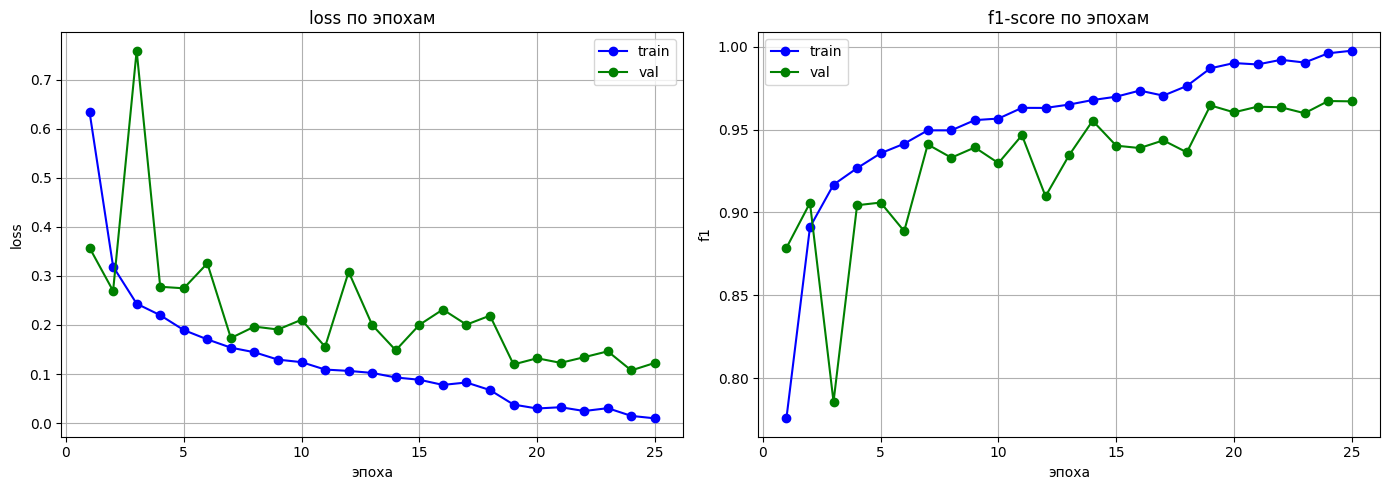

In [10]:
model1=train_model(model1, optimizer1, scheduler1, 25, 'model1', device)

эпоха 1 val: 100%|██████████| 173/173 [00:36<00:00,  4.72it/s]


эпоха 1:
train: loss = 0.700, f1 = 0.752
val: loss = 0.323, f1 = 0.889


эпоха 2 val: 100%|██████████| 173/173 [00:35<00:00,  4.92it/s]


эпоха 2:
train: loss = 0.362, f1 = 0.876
val: loss = 0.397, f1 = 0.860


эпоха 3 val: 100%|██████████| 173/173 [00:36<00:00,  4.70it/s]


...

эпоха 23:
train: loss = 0.086, f1 = 0.971
val: loss = 0.138, f1 = 0.960


эпоха 24 val: 100%|██████████| 173/173 [00:37<00:00,  4.63it/s]


эпоха 24:
train: loss = 0.078, f1 = 0.974
val: loss = 0.117, f1 = 0.967


эпоха 25 val: 100%|██████████| 173/173 [00:37<00:00,  4.57it/s]


эпоха 25:
train: loss = 0.075, f1 = 0.973
val: loss = 0.203, f1 = 0.943


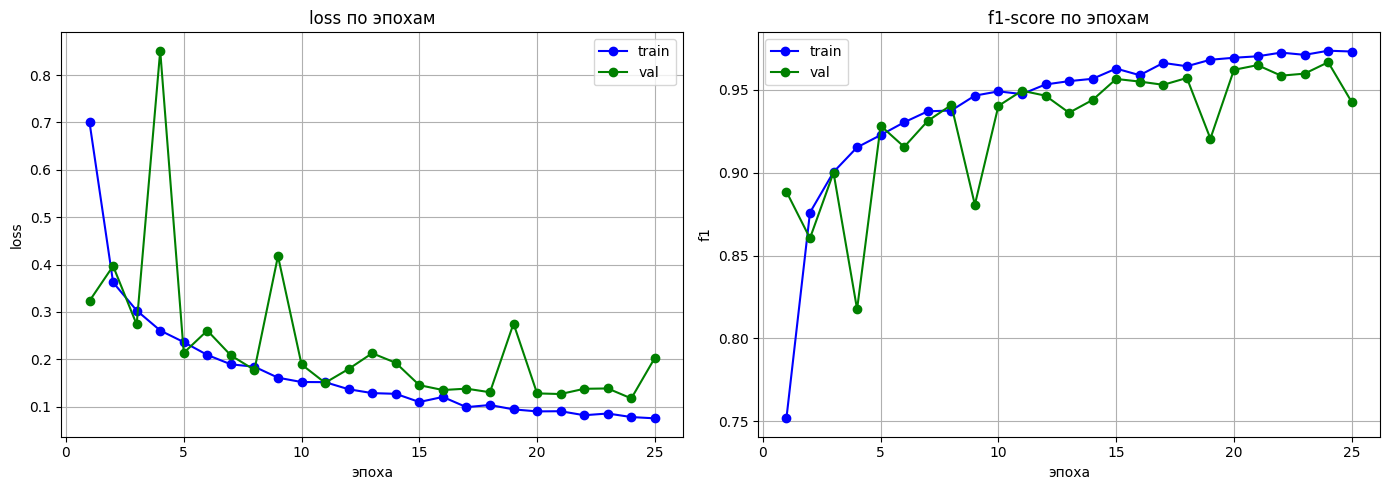

In [11]:
model2=train_model(model2, optimizer2, scheduler2, 25, 'model2', device)

### Тестирование модели
Функция `test_model()` вычисляет weighted F1, classification report и confusion matrix.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def test_model(model, class_names, device):
    model.eval()
    model=model.to(device)
    preds=[]
    labels=[]
    with torch.no_grad():
        for X_te, y_te in tqdm(test_loader, desc='test'):
            X_te, y_te=X_te.to(device), y_te.to(device)
            y_pr=torch.max(model(X_te), 1)[1]
            preds.extend(y_pr.cpu().numpy())
            labels.extend(y_te.cpu().numpy())
    f1_score=f1_score(labels,preds, average='weighted')
    print(f'\nf1-score: {f1_score:.3f}')
    print(f'\nclassification report:\n{classification_report(labels,preds,target_names=class_names)}\n')

    # матрица ошибок
    plt.figure(figsize=(10,8))
    cm=confusion_matrix(labels,preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title('confusion matrix')
    plt.xlabel('predicted')
    plt.ylabel('true')
    plt.tight_layout()

    return f1

In [16]:
def test_model(model, class_names, device):
    model.eval()
    model = model.to(device)
    preds = []
    labels = []
    with torch.no_grad():
        for X_te, y_te in tqdm(test_loader, desc='test'):
            X_te, y_te = X_te.to(device), y_te.to(device)
            y_pr = torch.max(model(X_te), 1)[1]
            preds.extend(y_pr.cpu().numpy())
            labels.extend(y_te.cpu().numpy())
    
    f1 = f1_score(labels, preds, average='weighted')
    print(f'\nf1-score: {f1:.3f}')
    print(f'\nclassification report:\n{classification_report(labels, preds, target_names=class_names)}\n')
    
    # матрица ошибок
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title('confusion matrix')
    plt.xlabel('predicted')
    plt.ylabel('true')
    plt.tight_layout()
    plt.show()
    
    return f1

test: 100%|██████████| 87/87 [00:18<00:00,  4.67it/s]



f1-score: 0.969

classification report:
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.94      0.94       300
              Forest       1.00      1.00      1.00       300
HerbaceousVegetation       0.97      0.94      0.95       300
             Highway       0.94      0.98      0.96       250
          Industrial       0.99      0.98      0.99       250
             Pasture       0.96      0.93      0.94       200
       PermanentCrop       0.91      0.94      0.92       250
         Residential       0.99      0.99      0.99       300
               River       0.99      0.99      0.99       250
             SeaLake       0.99      1.00      0.99       359

            accuracy                           0.97      2759
           macro avg       0.97      0.97      0.97      2759
        weighted avg       0.97      0.97      0.97      2759




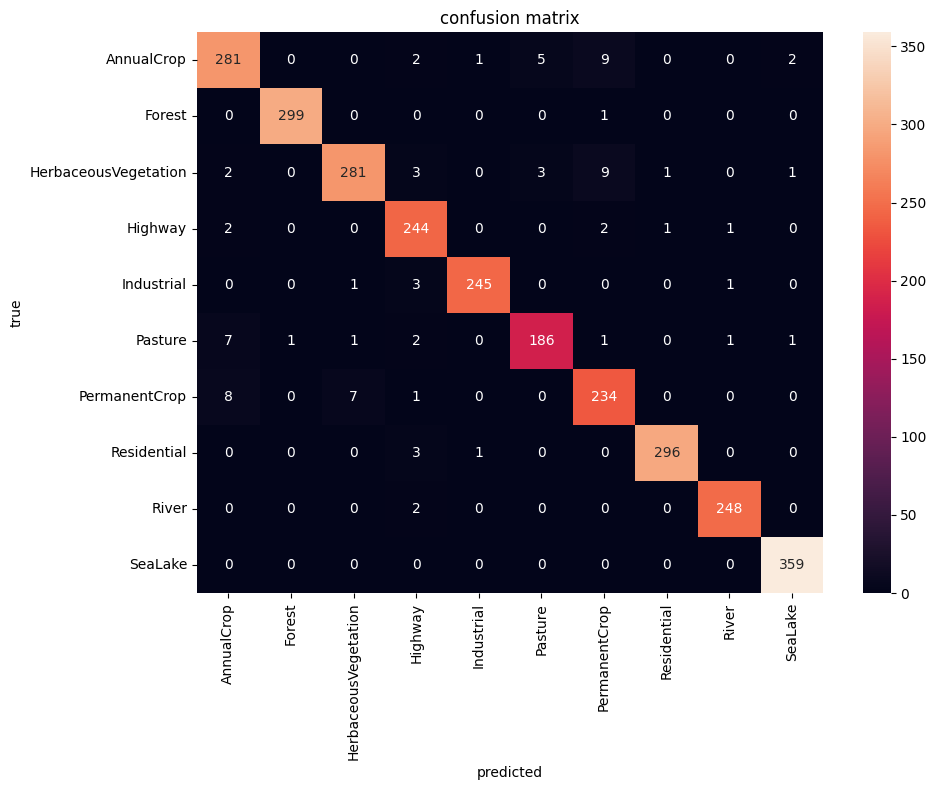

In [17]:
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 
               'River', 'SeaLake']

f1_1 = test_model(model1, class_names, device)

test: 100%|██████████| 87/87 [00:17<00:00,  4.84it/s]



f1-score: 0.965

classification report:
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.95      0.94       300
              Forest       0.99      1.00      1.00       300
HerbaceousVegetation       0.94      0.94      0.94       300
             Highway       0.95      0.96      0.95       250
          Industrial       0.99      0.96      0.98       250
             Pasture       0.98      0.94      0.96       200
       PermanentCrop       0.93      0.89      0.91       250
         Residential       0.98      1.00      0.99       300
               River       0.95      1.00      0.97       250
             SeaLake       0.99      1.00      1.00       359

            accuracy                           0.97      2759
           macro avg       0.96      0.96      0.96      2759
        weighted avg       0.97      0.97      0.97      2759




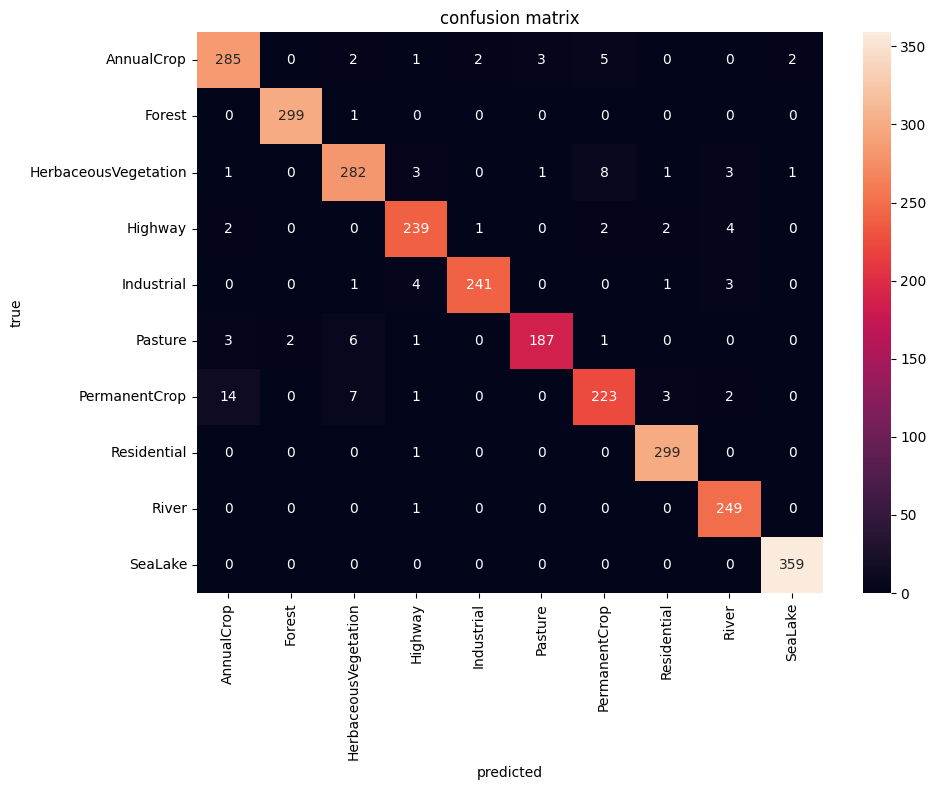

In [18]:
f1_2 = test_model(model2, class_names, device)